In [1]:
# Cell 1: Imports & basic config

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

from pandas.api.types import CategoricalDtype  # <-- NEW, from pandas, not sklearn

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
pd.set_option('display.max_columns', 200)


## Data Preprocessing

In [2]:
# Cell 2: Load raw data
DATA_PATH = "../data/bank_marketing.csv"
df_raw = pd.read_csv(DATA_PATH)
df_raw.rename(columns={"day_of_week": "day_of_month"}, inplace=True)

print(df_raw.shape)
df_raw.head()


(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_month,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [3]:
# Cell 3: Create 80/20 split (train_part1 vs holdout for Part 2)

# We assume 'y' is present in df_raw
assert 'y' in df_raw.columns, "Expected target column 'y' not found."

train_df, holdout_df = train_test_split(
    df_raw,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_raw['y']  # keep class balance
)

print("Train (Part 1) shape:", train_df.shape)
print("Holdout (Part 2) shape:", holdout_df.shape)

# Optional: save holdout so you don't accidentally touch it
holdout_df.to_csv("../data/bank_marketing_holdout.csv", index=False)


Train (Part 1) shape: (36168, 17)
Holdout (Part 2) shape: (9043, 17)


In [4]:
# Cell 4: Basic EDA on the 80% training data

train_df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day_of_month,month,duration,campaign,pdays,previous,poutcome,y
24001,36,technician,divorced,secondary,no,861,no,no,telephone,29,aug,140,2,-1,0,NaN,no
43409,24,student,single,secondary,no,4126,no,no,cellular,5,apr,907,4,185,7,failure,yes
20669,44,technician,single,secondary,no,244,yes,no,cellular,12,aug,1735,4,-1,0,NaN,yes
18810,48,unemployed,married,secondary,no,0,no,no,telephone,31,jul,35,11,-1,0,NaN,no
23130,38,technician,married,secondary,no,257,no,no,cellular,26,aug,57,10,-1,0,NaN,no


In [5]:
# Check types and missingness
train_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 36168 entries, 24001 to 44229
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           36168 non-null  int64 
 1   job           35934 non-null  object
 2   marital       36168 non-null  object
 3   education     34686 non-null  object
 4   default       36168 non-null  object
 5   balance       36168 non-null  int64 
 6   housing       36168 non-null  object
 7   loan          36168 non-null  object
 8   contact       25782 non-null  object
 9   day_of_month  36168 non-null  int64 
 10  month         36168 non-null  object
 11  duration      36168 non-null  int64 
 12  campaign      36168 non-null  int64 
 13  pdays         36168 non-null  int64 
 14  previous      36168 non-null  int64 
 15  poutcome      6579 non-null   object
 16  y             36168 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.0+ MB


In [6]:
# Distribution of target y
train_df['y'].value_counts(normalize=True)


y
no     0.883018
yes    0.116982
Name: proportion, dtype: float64

In [7]:
# Quick look at some numeric columns
numeric_preview_cols = ['age', 'balance', 'campaign', 'pdays', 'previous']
train_df[numeric_preview_cols].describe()


,age,balance,campaign,pdays,previous
count,36168.000000,36168.00000,36168.000000,36168.000000,36168.000000
mean,40.892999,1365.49342,2.763935,40.157238,0.581730
std,10.627075,3068.54350,3.104161,100.162614,2.408766
min,18.000000,-8019.00000,1.000000,-1.000000,0.000000
25%,33.000000,74.00000,1.000000,-1.000000,0.000000
50%,39.000000,451.00000,2.000000,-1.000000,0.000000
75%,48.000000,1430.25000,3.000000,-1.000000,0.000000
max,95.000000,102127.00000,63.000000,871.000000,275.000000


### Defining Targets and Dropping variables

In [8]:
# Cell 5: Define X, y for Part 1 training data & drop duration

df = train_df.copy()


# Map target
df['y'] = df['y'].map({'yes': 1, 'no': 0}).astype(int)

# Drop leakage feature
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
    print("Dropped 'duration' to avoid data leakage.")

X = df.drop(columns=['y'])
y = df['y']

X.head()


Dropped 'duration' to avoid data leakage.


,age,job,marital,education,default,balance,housing,loan,contact,day_of_month,month,campaign,pdays,previous,poutcome
24001,36,technician,divorced,secondary,no,861,no,no,telephone,29,aug,2,-1,0,NaN
43409,24,student,single,secondary,no,4126,no,no,cellular,5,apr,4,185,7,failure
20669,44,technician,single,secondary,no,244,yes,no,cellular,12,aug,4,-1,0,NaN
18810,48,unemployed,married,secondary,no,0,no,no,telephone,31,jul,11,-1,0,NaN
23130,38,technician,married,secondary,no,257,no,no,cellular,26,aug,10,-1,0,NaN


In [9]:
# Cell 6: Define numeric and categorical columns

# Based on the dictionary you copied
numeric_features = [
    'age',
    'balance',
    'campaign',
    'pdays',
    'previous'
]

# We'll treat these as categoricals
categorical_features = [
    'job',
    'marital',
    'education',
    'contact',
    'month',
    'day_of_month',
    'poutcome',
]

# Binary yes/no columns – convert to 0/1 and treat as numeric
binary_yes_no_features = ['default', 'housing', 'loan']

for col in binary_yes_no_features:
    if col in X.columns:
        X[col] = X[col].map({'yes': 1, 'no': 0}).astype(int)

# Add them to numeric features for scaling (or you can leave them unscaled)
numeric_features_extended = numeric_features + [c for c in binary_yes_no_features if c in X.columns]

print("Numeric features:", numeric_features_extended)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'balance', 'campaign', 'pdays', 'previous', 'default', 'housing', 'loan']
Categorical features: ['job', 'marital', 'education', 'contact', 'month', 'day_of_month', 'poutcome']


In [10]:
# ---- Engineered features ----

required_cols = ["age", "balance", "campaign", "pdays", "previous", "month", "day_of_month"]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing required columns in df: {missing}"

df["has_been_contacted_before"] = (df["pdays"] != -1).astype(int)
df["total_contacts"] = df["previous"] + df["campaign"]
df["high_campaign_pressure"] = (df["campaign"] >= 3).astype(int)
df["recent_contact"] = ((df["pdays"] >= 0) & (df["pdays"] <= 7)).astype(int)
df["long_pdays"] = ((df["pdays"] > 100) & (df["pdays"] != -1)).astype(int)


month_to_quarter = {
    "jan": 1, "feb": 1, "mar": 1,
    "apr": 2, "may": 2, "jun": 2,
    "jul": 3, "aug": 3, "sep": 3,
    "oct": 4, "nov": 4, "dec": 4,
}

# Create quarter as categorical
df["quarter_cat"] = df["month"].map(month_to_quarter).astype("category")

# Add quarter_cat to categorical features
if "quarter_cat" not in categorical_features:
    categorical_features.append("quarter_cat")



df["low_balance"] = (df["balance"] < 0).astype(int)

df["begin_month"] = (df["day_of_month"] <= 5).astype(int)
df["mid_month"]   = ((df["day_of_month"] >= 13) & (df["day_of_month"] <= 17)).astype(int)
df["end_month"]   = (df["day_of_month"] >= 25).astype(int)


q90 = df["balance"].quantile(0.9)
df["high_balance"] = (df["balance"] > q90).astype(int)

# balance_bin stays numeric
balance_bin = pd.qcut(df["balance"], q=5, labels=False, duplicates="drop")
df["balance_bin"] = balance_bin.astype(float)
df["balance_bin"].fillna(df["balance_bin"].median(), inplace=True)

# --- NEW: proper categorical age bins (for one-hot encoding) ---
age_bins = [17, 25, 40, 60, 100]
age_labels = ["age_18_25", "age_26_40", "age_41_60", "age_60_plus"]

df["age_bin"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
)

# 👉 Put the *baseline* (middle group) first in the category order
age_order = ["age_26_40", "age_18_25", "age_41_60", "age_60_plus"]
age_cat_type = CategoricalDtype(categories=age_order, ordered=True)

df["age_bin"] = df["age_bin"].astype(age_cat_type)

# df["senior"] = (df["age"] >= 60).astype(int)
# df["student_age"] = (df["age"] <= 25).astype(int)

df["interaction_campaign_prev"] = df["campaign"] * df["previous"]
df["interaction_pdays_prev"] = df["pdays"] * df["previous"]
df["interaction_age_balance"] = df["age"] * df["balance"]
df["interaction_balance_campaign"] = df["balance"] * df["campaign"]

# Map month to numbers for easy comparisons
month_to_num = {
    "jan": 1, "feb": 2, "mar": 3,
    "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9,
    "oct": 10, "nov": 11, "dec": 12
}
df["month_num"] = df["month"].map(month_to_num)

# Define each holiday window
winter_holiday = (
    ((df["month_num"] == 12) & (df["day_of_month"] >= 21)) |
    ((df["month_num"] == 1)  & (df["day_of_month"] <= 3))
)

thanksgiving = (
    (df["month_num"] == 11) &
    (df["day_of_month"].between(22, 30))
)

july4 = (
    (df["month_num"] == 7) &
    (df["day_of_month"].between(2, 9))
)

easter = (
    (df["month_num"] == 4) &
    (df["day_of_month"].between(10, 17))
)

# Combine all into ONE feature
df["is_holiday_period"] = (
    winter_holiday |
    thanksgiving   |
    july4          |
    easter         
).astype(int)

# Numeric engineered features (everything except age_bin, which is categorical)
engineered_numeric = [
    "has_been_contacted_before",
    "total_contacts",
    "high_campaign_pressure",
    "recent_contact",
    "long_pdays",
    "low_balance",
    "high_balance",
    "balance_bin",
    "interaction_campaign_prev",
    "interaction_pdays_prev",
    "interaction_age_balance",
    "interaction_balance_campaign",
    "begin_month",
    "mid_month",
    "end_month",
    "is_holiday_period"
]

for col in engineered_numeric:
    if col not in numeric_features_extended:
        numeric_features_extended.append(col)

# Add age_bin as categorical
if "age_bin" not in categorical_features:
    categorical_features.append("age_bin")

X = df.drop(columns=["y"])
y = df["y"].copy()

print("\nNew X shape (with engineered features):", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))
print("\nUpdated numeric_features_extended:")
print(numeric_features_extended)
print("\nUpdated categorical_features:")
print(categorical_features)



New X shape (with engineered features): (36168, 34)
y distribution:
 y
0    0.883018
1    0.116982
Name: proportion, dtype: float64

Updated numeric_features_extended:
['age', 'balance', 'campaign', 'pdays', 'previous', 'default', 'housing', 'loan', 'has_been_contacted_before', 'total_contacts', 'high_campaign_pressure', 'recent_contact', 'long_pdays', 'low_balance', 'high_balance', 'balance_bin', 'interaction_campaign_prev', 'interaction_pdays_prev', 'interaction_age_balance', 'interaction_balance_campaign', 'begin_month', 'mid_month', 'end_month', 'is_holiday_period']

Updated categorical_features:
['job', 'marital', 'education', 'contact', 'month', 'day_of_month', 'poutcome', 'quarter_cat', 'age_bin']


/var/folders/z6/ndbgj9316gnck992qd53wwkm0000gn/T/ipykernel_31406/25689086.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["balance_bin"].fillna(df["balance_bin"].median(), inplace=True)


,spearman_rho
previous,0.165842
has_been_contacted_before,0.163589
interaction_campaign_prev,0.162069
interaction_pdays_prev,0.158440
pdays,0.150446
balance,0.101553
balance_bin,0.099533
interaction_age_balance,0.098811
long_pdays,0.087888
interaction_balance_campaign,0.069370


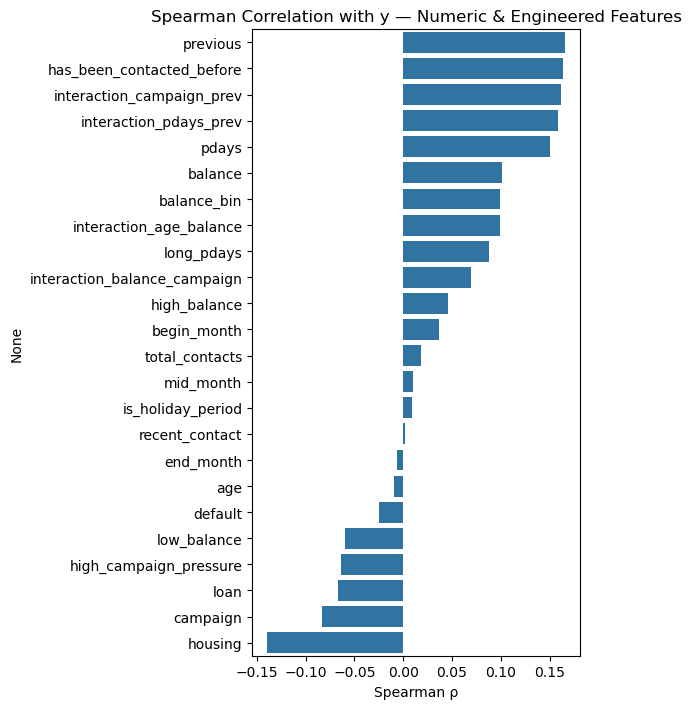

In [11]:
# Cell 8: Spearman correlation between numeric-like features and y

diag_df = df.copy()
# ensure numeric/binary columns are numeric
for col in ['default', 'housing', 'loan']:
    if col in diag_df.columns and diag_df[col].dtype == "object":
        diag_df[col] = diag_df[col].map({'yes': 1, 'no': 0})

corr_with_y = (
    diag_df[numeric_features_extended + ["y"]]
    .corr(method="spearman")["y"]
    .drop("y")
    .sort_values(ascending=False)
)

display(corr_with_y.to_frame(name="spearman_rho"))

plt.figure(figsize=(6, max(2, 0.3 * len(corr_with_y))))
sns.barplot(x=corr_with_y.values, y=corr_with_y.index, orient="h")
plt.title("Spearman Correlation with y — Numeric & Engineered Features")
plt.xlabel("Spearman ρ")
plt.tight_layout()
plt.show()


In [12]:
# Cell 9: Cramér's V helper

import scipy.stats as ss

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


,feature,cramers_v_y
6,poutcome,0.473210
4,month,0.256753
8,age_bin,0.175380
0,job,0.137266
5,day_of_month,0.110669
7,quarter_cat,0.098838
2,education,0.070501
1,marital,0.067749
3,contact,0.003243


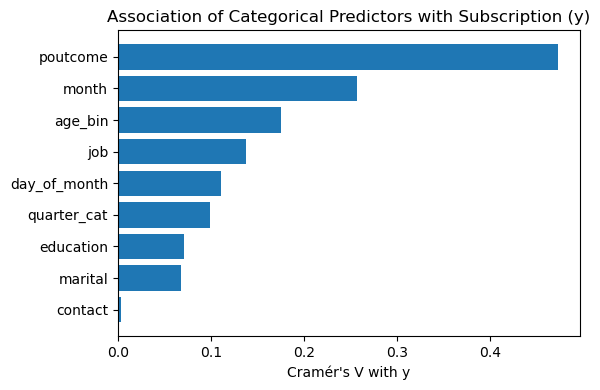

In [13]:
# Cell 10: Cramér's V between each categorical feature and y

rows = []
for col in categorical_features:
    v = cramers_v(df[col], df['y'])
    rows.append({"feature": col, "cramers_v_y": v})

cramers_vs_y = pd.DataFrame(rows).sort_values("cramers_v_y", ascending=False)
display(cramers_vs_y)

plt.figure(figsize=(6, 4))
plt.barh(cramers_vs_y['feature'], cramers_vs_y['cramers_v_y'])
plt.gca().invert_yaxis()
plt.xlabel("Cramér's V with y")
plt.title("Association of Categorical Predictors with Subscription (y)")
plt.tight_layout()
plt.show()


In [14]:
# Cell 11: Prepare data for L1 logistic regression

# Ensure binary yes/no columns are numeric (if any object left)
for col in ["default", "housing", "loan"]:
    if col in df.columns and df[col].dtype == "object":
        df[col] = df[col].map({"yes": 1, "no": 0}).astype(int)

numeric_cols = numeric_features_extended.copy()
cat_cols_l1 = categorical_features.copy()

X_l1 = df[numeric_cols + cat_cols_l1].copy()
y_l1 = df["y"].copy()

print("Numeric cols for L1:", numeric_cols)
print("Categorical cols for L1:", cat_cols_l1)
print("X_l1 shape:", X_l1.shape)


Numeric cols for L1: ['age', 'balance', 'campaign', 'pdays', 'previous', 'default', 'housing', 'loan', 'has_been_contacted_before', 'total_contacts', 'high_campaign_pressure', 'recent_contact', 'long_pdays', 'low_balance', 'high_balance', 'balance_bin', 'interaction_campaign_prev', 'interaction_pdays_prev', 'interaction_age_balance', 'interaction_balance_campaign', 'begin_month', 'mid_month', 'end_month', 'is_holiday_period']
Categorical cols for L1: ['job', 'marital', 'education', 'contact', 'month', 'day_of_month', 'poutcome', 'quarter_cat', 'age_bin']
X_l1 shape: (36168, 33)


In [15]:
# Cell 12: L1-regularized Logistic Regression with cross-validated C

preprocessor_l1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols_l1),
    ]
)



In [16]:
C_grid = [0.2, 0.1, 0.05, 0.01]

summaries_by_C = {}

for C_val in C_grid:
    print(f"\n=== L1 Logistic Regression with C = {C_val} ===")
    
    logreg_l1 = LogisticRegression(
        C=C_val,
        penalty="l1",
        solver="saga",
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )

    l1_pipeline = Pipeline([
        ("preprocess", preprocessor_l1),
        ("clf", logreg_l1),
    ])

    l1_pipeline.fit(X_l1, y_l1)

    pre = l1_pipeline.named_steps["preprocess"]
    ohe = pre.named_transformers_["cat"]

    num_feature_names = numeric_cols
    cat_feature_names = ohe.get_feature_names_out(cat_cols_l1)
    all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

    coefs = l1_pipeline.named_steps["clf"].coef_.ravel()

    sparsity_df = pd.DataFrame({
        "feature_full": all_feature_names,
        "coef": coefs,
    })
    sparsity_df["abs_coef"] = sparsity_df["coef"].abs()
    sparsity_df["non_zero"] = (sparsity_df["abs_coef"] > 1e-6).astype(int)

    def get_orig_feature(name: str) -> str:
        if name in numeric_cols:
            return name
        # map one-hot names back to their original categorical column
        for col in cat_cols_l1:
            if name.startswith(col + "_"):
                return col
        return name


    sparsity_df["orig_feature"] = sparsity_df["feature_full"].apply(get_orig_feature)

    summary = (
        sparsity_df
        .groupby("orig_feature")
        .agg(
            n_terms     = ("feature_full", "count"),
            n_non_zero  = ("non_zero", "sum"),
            max_abs_coef= ("abs_coef", "max"),
        )
        .reset_index()
    )
    summary["frac_non_zero"] = summary["n_non_zero"] / summary["n_terms"]

    # store & display per-C table
    summaries_by_C[C_val] = summary.sort_values("frac_non_zero", ascending=False)
    print(f"\n=== L1 Logistic Regression with C = {C_val} ===")
    
    display(summaries_by_C[C_val])



=== L1 Logistic Regression with C = 0.2 ===

=== L1 Logistic Regression with C = 0.2 ===


,orig_feature,n_terms,n_non_zero,max_abs_coef,frac_non_zero
0,age,1,1,0.081410,1.000000
1,age_bin,3,3,0.733003,1.000000
31,recent_contact,1,1,0.051685,1.000000
30,quarter_cat,3,3,0.332604,1.000000
29,previous,1,1,0.149739,1.000000
28,poutcome,3,3,2.169979,1.000000
27,pdays,1,1,0.175939,1.000000
26,month,11,11,1.143971,1.000000
25,mid_month,1,1,0.067329,1.000000
23,low_balance,1,1,0.001607,1.000000



=== L1 Logistic Regression with C = 0.1 ===

=== L1 Logistic Regression with C = 0.1 ===


,orig_feature,n_terms,n_non_zero,max_abs_coef,frac_non_zero
0,age,1,1,0.079071,1.000000
14,housing,1,1,0.210649,1.000000
31,recent_contact,1,1,0.050572,1.000000
30,quarter_cat,3,3,0.325954,1.000000
29,previous,1,1,0.141618,1.000000
27,pdays,1,1,0.168985,1.000000
26,month,11,11,1.143891,1.000000
25,mid_month,1,1,0.079542,1.000000
23,low_balance,1,1,0.001179,1.000000
22,long_pdays,1,1,0.312307,1.000000



=== L1 Logistic Regression with C = 0.05 ===

=== L1 Logistic Regression with C = 0.05 ===


,orig_feature,n_terms,n_non_zero,max_abs_coef,frac_non_zero
0,age,1,1,0.069980,1.000000
14,housing,1,1,0.215650,1.000000
31,recent_contact,1,1,0.048228,1.000000
30,quarter_cat,3,3,0.275669,1.000000
29,previous,1,1,0.127535,1.000000
27,pdays,1,1,0.155320,1.000000
26,month,11,11,1.063429,1.000000
25,mid_month,1,1,0.086240,1.000000
23,low_balance,1,1,0.000247,1.000000
22,long_pdays,1,1,0.294367,1.000000



=== L1 Logistic Regression with C = 0.01 ===

=== L1 Logistic Regression with C = 0.01 ===


,orig_feature,n_terms,n_non_zero,max_abs_coef,frac_non_zero
11,has_been_contacted_before,1,1,0.143157,1.000000
29,previous,1,1,0.045834,1.000000
21,loan,1,1,0.104428,1.000000
19,is_holiday_period,1,1,0.008465,1.000000
25,mid_month,1,1,0.056499,1.000000
17,interaction_campaign_prev,1,1,0.012414,1.000000
1,age_bin,3,3,0.412611,1.000000
14,housing,1,1,0.239156,1.000000
27,pdays,1,1,0.066240,1.000000
24,marital,2,2,0.293179,1.000000


In [17]:
# ============================================================
# Lock in FINAL feature set for model selection
# ============================================================

# 1. Define final numeric and categorical features
final_numeric_features = [
    # Contact history / intensity
    "previous",
    "campaign",
    "pdays",
    "recent_contact",
    "interaction_campaign_prev",
    
    # Balance / wealth
    "balance_bin",
    
    # Timing
    "is_holiday_period",
    
    # Other binary indicators
    "housing",
    "loan",
]

final_categorical_features = [
    # Person demographics
    "marital",
    "job",
    "education",
    "age_bin",          # categorical age buckets
    
    # Timing of call
    "month",
    
    # Campaign outcome history
    "contact",
    "poutcome",
]

# 2. Sanity-check that all chosen columns exist in df
missing_final = [
    col for col in (final_numeric_features + final_categorical_features)
    if col not in df.columns
]
assert len(missing_final) == 0, f"Missing columns in df: {missing_final}"

# 3. Build final X, y for model selection
X_final = df[final_numeric_features + final_categorical_features].copy()
y_final = df["y"].copy()

print("Final numeric features:", final_numeric_features)
print("Final categorical features:", final_categorical_features)
print("X_final shape:", X_final.shape)
print("y_final distribution:\n", y_final.value_counts(normalize=True))


Final numeric features: ['previous', 'campaign', 'pdays', 'recent_contact', 'interaction_campaign_prev', 'balance_bin', 'is_holiday_period', 'housing', 'loan']
Final categorical features: ['marital', 'job', 'education', 'age_bin', 'month', 'contact', 'poutcome']
X_final shape: (36168, 16)
y_final distribution:
 y
0    0.883018
1    0.116982
Name: proportion, dtype: float64


In [46]:
# 4. (Optional) define final ColumnTransformer for downstream models
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), final_numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),
         final_categorical_features),
    ]
)

## Model Selection

In [47]:

import os, json, warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
os.makedirs("../models", exist_ok=True)

# Cross-validation and scoring
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORERS = {
    "f1": "f1",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
}

# For our business case we care most about recall; could also choose "f1"
PRIMARY = "roc_auc"

In [48]:

def run_search(
    name,
    base_estimator,
    param_grid,
    search="grid",
    n_iter=20,
):
    """
    name: str, model name label
    base_estimator: sklearn estimator (e.g., LogisticRegression())
    param_grid: dict of hyperparameters (without 'clf__' prefix)
    search: "grid" or "random"
    n_iter: for random search
    """

    # Wrap preprocessor + model using FINAL feature set
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor_final),
        ("clf", base_estimator),
    ])

    # Prefix params with 'clf__' so GridSearchCV knows they belong to the model
    param_grid_prefixed = {f"clf__{k}": v for k, v in param_grid.items()}

    if search == "grid":
        searcher = GridSearchCV(
            pipe,
            param_grid=param_grid_prefixed,
            scoring=SCORERS,
            refit=PRIMARY,
            cv=cv,
            n_jobs=-1,
            verbose=1,
        )
    else:
        searcher = RandomizedSearchCV(
            pipe,
            param_distributions=param_grid_prefixed,
            n_iter=n_iter,
            scoring=SCORERS,
            refit=PRIMARY,
            cv=cv,
            n_jobs=-1,
            random_state=42,
            verbose=1,
        )

    # >>> IMPORTANT: use X_final, y_final <<<
    searcher.fit(X_final, y_final)

    # Pull out CV results for leaderboard
    best_idx = searcher.best_index_
    cv_res = searcher.cv_results_

    row = {
        "Model": name,
        "BestParams": searcher.best_params_,
        "mean_test_f1": cv_res["mean_test_f1"][best_idx],
        "std_test_f1": cv_res["std_test_f1"][best_idx],
        "mean_test_accuracy": cv_res["mean_test_accuracy"][best_idx],
        "mean_test_precision": cv_res["mean_test_precision"][best_idx],
        "mean_test_recall": cv_res["mean_test_recall"][best_idx],
        "mean_test_roc_auc": cv_res["mean_test_roc_auc"][best_idx],
    }

    return searcher.best_estimator_, row

In [49]:
# Cell 4.1: containers for model search results

results = []          # list of dicts for leaderboard rows
best_models = {}      # name -> best fitted pipeline


In [50]:
# Cell 4.2: Logistic Regression — L1 (LASSO)

param_grid_logreg_l1 = {
    "penalty": ["l1"],
    "solver": ["liblinear", "saga"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
}

best_models["LogReg_L1"], row = run_search(
    name="LogReg_L1",
    base_estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    param_grid=param_grid_logreg_l1,
    search="grid",
)

results.append(row)
row


Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'Model': 'LogReg_L1',
 'BestParams': {'clf__C': 0.1,
  'clf__penalty': 'l1',
  'clf__solver': 'liblinear'},
 'mean_test_f1': np.float64(0.38814780858640496),
 'std_test_f1': np.float64(0.006571635571158961),
 'mean_test_accuracy': np.float64(0.7670591287795956),
 'mean_test_precision': np.float64(0.28023544834283276),
 'mean_test_recall': np.float64(0.6315300001953774),
 'mean_test_roc_auc': np.float64(0.7727923079678272)}

In [51]:
# Cell 4.3: Logistic Regression — L2 (ridge-style)

param_grid_logreg_l2 = {
    "penalty": ["l2"],
    "solver": ["liblinear", "lbfgs", "saga"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
}

best_models["LogReg_L2"], row = run_search(
    name="LogReg_L2",
    base_estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    param_grid=param_grid_logreg_l2,
    search="grid",
)

results.append(row)
row


Fitting 5 folds for each of 18 candidates, totalling 90 fits


{'Model': 'LogReg_L2',
 'BestParams': {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'saga'},
 'mean_test_f1': np.float64(0.3871660023535159),
 'std_test_f1': np.float64(0.006370303732554431),
 'mean_test_accuracy': np.float64(0.7666167770587002),
 'mean_test_precision': np.float64(0.27949186387204883),
 'mean_test_recall': np.float64(0.630112956031718),
 'mean_test_roc_auc': np.float64(0.7726564969500771)}

In [52]:
# Cell 4.4: Logistic Regression — Elastic Net

param_grid_logreg_en = {
    "penalty": ["elasticnet"],
    "solver": ["saga"],
    "C": [0.001, 0.01, 0.1, 1, 10],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

best_models["LogReg_EN"], row = run_search(
    name="LogReg_EN",
    base_estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    param_grid=param_grid_logreg_en,
    search="grid",
)

results.append(row)
row


Fitting 5 folds for each of 25 candidates, totalling 125 fits


{'Model': 'LogReg_EN',
 'BestParams': {'clf__C': 0.1,
  'clf__l1_ratio': 0.9,
  'clf__penalty': 'elasticnet',
  'clf__solver': 'saga'},
 'mean_test_f1': np.float64(0.38786530516813567),
 'std_test_f1': np.float64(0.007385798234569417),
 'mean_test_accuracy': np.float64(0.7666996652098458),
 'mean_test_precision': np.float64(0.2798926960961362),
 'mean_test_recall': np.float64(0.6317664068147627),
 'mean_test_roc_auc': np.float64(0.7727602418830959)}

In [53]:
# Cell 4.5: Logistic Regression — no regularization (baseline GLM)

param_grid_logreg_none = {
    "penalty": [None],
    "solver": ["lbfgs"],
}

best_models["LogReg_None"], row = run_search(
    name="LogReg_None",
    base_estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    param_grid=param_grid_logreg_none,
    search="grid",
)

results.append(row)
row


Fitting 5 folds for each of 1 candidates, totalling 5 fits


{'Model': 'LogReg_None',
 'BestParams': {'clf__penalty': None, 'clf__solver': 'lbfgs'},
 'mean_test_f1': np.float64(0.38813707713014617),
 'std_test_f1': np.float64(0.006546536433062387),
 'mean_test_accuracy': np.float64(0.768607499319331),
 'mean_test_precision': np.float64(0.28106506000191545),
 'mean_test_recall': np.float64(0.6272777512622774),
 'mean_test_roc_auc': np.float64(0.7724417307334732)}

In [54]:
# Cell 4.6: Random Forest

param_grid_rf = {
    "n_estimators": [200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

best_models["RF"], row = run_search(
    name="RandomForest",
    base_estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    param_grid=param_grid_rf,
    search="random",
    n_iter=24,
)

results.append(row)
row


Fitting 5 folds for each of 24 candidates, totalling 120 fits


{'Model': 'RandomForest',
 'BestParams': {'clf__n_estimators': 300,
  'clf__min_samples_split': 2,
  'clf__min_samples_leaf': 4,
  'clf__max_features': 'log2',
  'clf__max_depth': 20},
 'mean_test_f1': np.float64(0.44888662433837556),
 'std_test_f1': np.float64(0.0037439791838658003),
 'mean_test_accuracy': np.float64(0.8427337899769057),
 'mean_test_precision': np.float64(0.380683691317189),
 'mean_test_recall': np.float64(0.5473898978734569),
 'mean_test_roc_auc': np.float64(0.7816336690034793)}

In [55]:
# Cell 4.7 (optional): XGBoost
# Run this cell only if xgboost is installed.

from xgboost import XGBClassifier

pos = y_final.sum()
neg = len(y_final) - pos
spw = neg / max(pos, 1)  # scale_pos_weight for imbalance

param_grid_xgb = {
    "n_estimators": [300, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.02, 0.05, 0.1],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "reg_lambda": [0.0, 1.0, 5.0],
    "reg_alpha": [0.0, 0.5, 1.0],
}

best_models["XGB"], row = run_search(
    name="XGBoost",
    base_estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=spw,
    ),
    param_grid=param_grid_xgb,
    search="random",
    n_iter=32,
)

results.append(row)
row


Fitting 5 folds for each of 32 candidates, totalling 160 fits


{'Model': 'XGBoost',
 'BestParams': {'clf__subsample': 1.0,
  'clf__reg_lambda': 5.0,
  'clf__reg_alpha': 0.0,
  'clf__n_estimators': 600,
  'clf__max_depth': 3,
  'clf__learning_rate': 0.05,
  'clf__colsample_bytree': 1.0},
 'mean_test_f1': np.float64(0.41864565082777777),
 'std_test_f1': np.float64(0.007075432079803886),
 'mean_test_accuracy': np.float64(0.7972241509277606),
 'mean_test_precision': np.float64(0.31524313170464013),
 'mean_test_recall': np.float64(0.62373304752415),
 'mean_test_roc_auc': np.float64(0.7877449963522617)}

In [56]:
# Cell 4.8: Neural Network (MLPClassifier)

from sklearn.neural_network import MLPClassifier

param_grid_mlp = {
    "hidden_layer_sizes": [
        (32,),
        (64,),
        (32, 32),
        (64, 32),
    ],
    "activation": ["relu"],
    "alpha": [0.0001, 0.001, 0.01],  # L2 regularization on weights
    "learning_rate": ["adaptive"],   # lets LR decrease if validation plateaus
}

best_models["NeuralNet"], row = run_search(
    name="NeuralNet",
    base_estimator=MLPClassifier(
        max_iter=500,
        solver="adam",
        random_state=42,
        early_stopping=True,      # helps avoid overfitting
        validation_fraction=0.1,  # used internally for early stopping
        n_iter_no_change=10,      # default patience
    ),
    param_grid=param_grid_mlp,
    search="grid",
)

results.append(row)
row


Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'Model': 'NeuralNet',
 'BestParams': {'clf__activation': 'relu',
  'clf__alpha': 0.01,
  'clf__hidden_layer_sizes': (64,),
  'clf__learning_rate': 'adaptive'},
 'mean_test_f1': np.float64(0.31332156061954813),
 'std_test_f1': np.float64(0.009261495725359009),
 'mean_test_accuracy': np.float64(0.8920316946554172),
 'mean_test_precision': np.float64(0.6122005595490971),
 'mean_test_recall': np.float64(0.210590849082145),
 'mean_test_roc_auc': np.float64(0.7800277888622966)}

In [57]:
# Cell 5.1: Build leaderboard sorted by PRIMARY metric (e.g., recall)

leaderboard = pd.DataFrame(results).sort_values(
    f"mean_test_{PRIMARY}", ascending=False
).reset_index(drop=True)

display(
    leaderboard[
        [
            "Model",
            "BestParams",
            "mean_test_f1",
            "std_test_f1",
            "mean_test_accuracy",
            "mean_test_precision",
            "mean_test_recall",
            "mean_test_roc_auc",
        ]
    ]
)


,Model,BestParams,mean_test_f1,std_test_f1,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc
0,XGBoost,"{'clf__subsample': 1.0, 'clf__reg_lambda': 5.0...",0.418646,0.007075,0.797224,0.315243,0.623733,0.787745
1,RandomForest,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.448887,0.003744,0.842734,0.380684,0.547390,0.781634
2,NeuralNet,"{'clf__activation': 'relu', 'clf__alpha': 0.01...",0.313322,0.009261,0.892032,0.612201,0.210591,0.780028
3,LogReg_L1,"{'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__so...",0.388148,0.006572,0.767059,0.280235,0.631530,0.772792
4,LogReg_EN,"{'clf__C': 0.1, 'clf__l1_ratio': 0.9, 'clf__pe...",0.387865,0.007386,0.766700,0.279893,0.631766,0.772760
5,LogReg_L2,"{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so...",0.387166,0.006370,0.766617,0.279492,0.630113,0.772656
6,LogReg_None,"{'clf__penalty': None, 'clf__solver': 'lbfgs'}",0.388137,0.006547,0.768607,0.281065,0.627278,0.772442


## Parameter Tuning

### Hypeparameter Refinement

In [64]:
from xgboost import XGBClassifier

# Recompute scale_pos_weight using the FINAL y
pos = y_final.sum()
neg = len(y_final) - pos
spw = neg / max(pos, 1)

# ------------------------------------------------------------
# FINE hyperparameter search around the first-round optimum
# ------------------------------------------------------------
param_grid_xgb_fine = {
    # around 600 trees
    "n_estimators": [550, 600, 650],
    
    # depth slightly around 3
    "max_depth": [2, 3, 4],
    
    # learning rate around 0.05
    "learning_rate": [0.04, 0.05, 0.06],
    
    # subsample / colsample slightly below 1 and at 1
    "subsample": [0.95, 1.0],
    "colsample_bytree": [0.95, 1.0],
    
    # regularization around lambda=5, alpha small
    "reg_lambda": [4.0, 5.0, 6.0],
    "reg_alpha": [0.0, 0.1, 0.2],
}

best_models["XGBoost_fine"], row = run_search(
    name="XGBoost_fine",
    base_estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=spw,
    ),
    param_grid=param_grid_xgb_fine,
    search="random",   # or "grid" if you want to try all combos
    n_iter=32,         # tweak if you want fewer/more samples
)

results.append(row)
row


Fitting 5 folds for each of 32 candidates, totalling 160 fits


{'Model': 'XGBoost_fine',
 'BestParams': {'clf__subsample': 1.0,
  'clf__reg_lambda': 6.0,
  'clf__reg_alpha': 0.0,
  'clf__n_estimators': 550,
  'clf__max_depth': 3,
  'clf__learning_rate': 0.04,
  'clf__colsample_bytree': 0.95},
 'mean_test_f1': np.float64(0.4188938932578292),
 'std_test_f1': np.float64(0.009183754899026876),
 'mean_test_accuracy': np.float64(0.7967540793603305),
 'mean_test_precision': np.float64(0.3150853060178697),
 'mean_test_recall': np.float64(0.6256240213687022),
 'mean_test_roc_auc': np.float64(0.7874265894271476)}

In [ ]:
# ============================================================
# Step 6: Threshold tuning for the chosen XGBoost model
# ============================================================
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

# 1) Grab the best XGBoost pipeline found in model selection
best_xgb = best_models["XGBoost_fine"]  # name must match the key you used above

# 2) Get out-of-fold predicted probabilities on the 80% training data
#    This refits the model in each fold and predicts on the held-out fold.
#    That way, each prediction is "honest" (no leakage).
y_oof_proba = cross_val_predict(
    best_xgb,
    X_final,
    y_final,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]  # probability of class 1 ("yes")

print("y_oof_proba shape:", y_oof_proba.shape)

# 3) Sweep a grid of thresholds and compute precision/recall/F1
thresholds = np.linspace(0.05, 0.95, 19)

rows = []
for t in thresholds:
    y_pred = (y_oof_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "recall": recall_score(y_final, y_pred, zero_division=0),
        "precision": precision_score(y_final, y_pred, zero_division=0),
        "f1": f1_score(y_final, y_pred, zero_division=0),
    })

thresh_df = pd.DataFrame(rows)
display(thresh_df)


y_oof_proba shape: (36168,)


,threshold,recall,precision,f1
0,0.05,0.999055,0.117502,0.210272
1,0.10,0.997636,0.118811,0.212335
2,0.15,0.988182,0.123028,0.218815
3,0.20,0.965965,0.133453,0.234508
4,0.25,0.928149,0.147355,0.254331
5,0.30,0.877807,0.167222,0.280927
6,0.35,0.816828,0.193267,0.312576
7,0.40,0.745214,0.226574,0.347495
8,0.45,0.683290,0.269457,0.386497
9,0.50,0.623730,0.314879,0.418490


In [65]:
# Add positive rate (fraction of points predicted "yes" at each threshold)
pos_rates = []
for t in thresholds:
    y_pred = (y_oof_proba >= t).astype(int)
    pos_rates.append(y_pred.mean())

thresh_df["positive_rate"] = pos_rates

display(thresh_df)


,threshold,recall,precision,f1,positive_rate
0,0.05,0.999055,0.117502,0.210272,0.994636
1,0.10,0.997636,0.118811,0.212335,0.982277
2,0.15,0.988182,0.123028,0.218815,0.939615
3,0.20,0.965965,0.133453,0.234508,0.846743
4,0.25,0.928149,0.147355,0.254331,0.736839
5,0.30,0.877807,0.167222,0.280927,0.614079
6,0.35,0.816828,0.193267,0.312576,0.494415
7,0.40,0.745214,0.226574,0.347495,0.384760
8,0.45,0.683290,0.269457,0.386497,0.296643
9,0.50,0.623730,0.314879,0.418490,0.231724


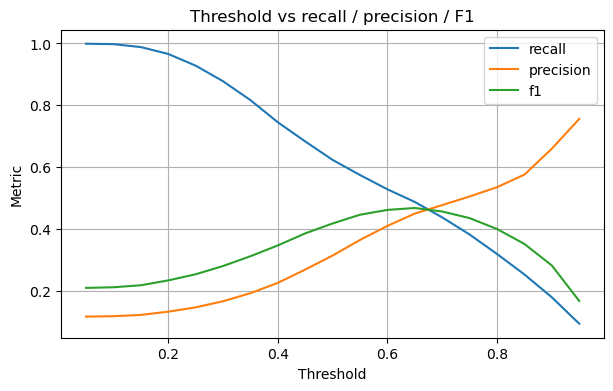

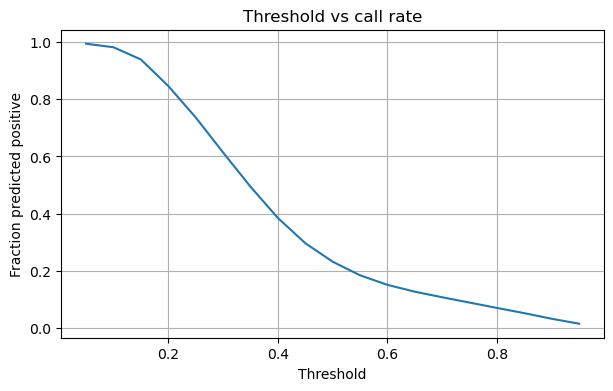

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(thresh_df["threshold"], thresh_df["recall"], label="recall")
plt.plot(thresh_df["threshold"], thresh_df["precision"], label="precision")
plt.plot(thresh_df["threshold"], thresh_df["f1"], label="f1")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.legend()
plt.title("Threshold vs recall / precision / F1")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(thresh_df["threshold"], thresh_df["positive_rate"])
plt.xlabel("Threshold")
plt.ylabel("Fraction predicted positive")
plt.title("Threshold vs call rate")
plt.grid(True)
plt.show()


In [67]:
# Refit the final XGB model on ALL the training data
best_xgb.fit(X_final, y_final)


,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
class Model:
    def __init__(self, model, threshold=0.35):
        self.model = model
        self.threshold = threshold
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)
    
    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)


In [69]:
final_model = Model(best_xgb, threshold=0.35)


In [73]:
final_predictions = final_model.predict_proba(X_final)


In [74]:
final_predictions

array([[0.6753473 , 0.32465267],
       [0.18378007, 0.8162199 ],
       [0.696476  , 0.30352405],
       ...,
       [0.67603946, 0.32396054],
       [0.39989984, 0.60010016],
       [0.26167953, 0.73832047]], shape=(36168, 2), dtype=float32)